# 03 - Results

Running the backtest, comparing against baselines, and splitting in-sample from out-of-sample.

**Discipline:** the sensitivity grid is evaluated on the *training* window only. The test window
is looked at once, at the end.

In [1]:
%matplotlib inline

import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Notebooks live in notebooks/; the package lives in src/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quant_platform import data, metrics, reporting, signals, validation
from quant_platform.returns import simple_returns, log_returns, cumulative_returns, rolling_volatility

reporting.apply_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 25)

UNIVERSE = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ", "DBC"]
print("quant_platform loaded from", ROOT / "src")

quant_platform loaded from C:\Users\monis\quant-research-platform\src


In [2]:
from quant_platform.portfolio import run_backtest

long = data.load_prices(UNIVERSE, "2007-01-01", "2025-12-31", data_dir=ROOT / "data", wide=False)
prices = data.to_wide(long, "adjusted_close").dropna()
returns = simple_returns(prices)

weights = signals.build_target_weights(prices, 252, 21, 3, "monthly", 0.40)
strategy = run_backtest(returns, weights, 100_000, commission_bps=2, slippage_bps=3,
                        execution_lag=1, name="Momentum (top 3)")
strategy

BacktestResult(name='Momentum (top 3)', 2008-02-01..2025-12-30, n=4507, final_equity=637,391)

## Baselines

Each isolates one claim the strategy implicitly makes.

In [3]:
baselines = validation.build_baselines(
    prices, returns, benchmark_symbol="SPY",
    lookback=252, skip=21, holdings=3, rebalance="monthly", max_weight=0.40,
    initial_capital=100_000, commission_bps=2, slippage_bps=3, execution_lag=1, seed=42,
)

results = validation.align_results({strategy.name: strategy, **baselines})
benchmark = results["SPY buy & hold"].net_returns

comparison = pd.DataFrame({
    name: metrics.summary_metrics(
        r.net_returns, equity=r.equity,
        benchmark=benchmark if name != "SPY buy & hold" else None,
        turnover=r.turnover, name=name,
    )
    for name, r in results.items()
})
comparison.loc[["cagr", "ann_volatility", "sharpe", "sortino", "max_drawdown",
                "calmar", "annual_turnover", "beta", "alpha", "information_ratio"]].round(3)

,Momentum (top 3),SPY buy & hold,Equal weight (all),Random selection,"Momentum, zero cost","Momentum, T+6 exec"
cagr,0.110289,0.11652,0.082665,0.066714,0.112689,0.092552
ann_volatility,0.14898,0.199326,0.157856,0.186236,0.149011,0.150015
sharpe,0.776929,0.65278,0.582235,0.439937,0.791297,0.665198
sortino,1.096835,0.923389,0.824879,0.62205,1.117883,0.939282
max_drawdown,-0.261766,-0.514815,-0.432705,-0.506614,-0.261519,-0.284379
calmar,0.421327,0.226333,0.191041,0.131685,0.430902,0.325453
annual_turnover,4.328743,0.0,0.0,15.822301,4.328743,4.384718
beta,0.46896,NaN,0.734904,0.797107,0.469104,0.478409
alpha,0.054728,NaN,-0.003713,-0.021784,0.056874,0.037541
information_ratio,-0.091496,NaN,-0.48317,-0.457848,-0.077718,-0.194864


### Reading this table honestly

The strategy has a higher Sharpe than SPY but a **lower CAGR**. It made less money while taking
less risk. Alpha is positive (beta-adjusted) while the information ratio is negative (not
beta-adjusted) — both correct, measuring different things.

In [4]:
row = comparison.loc[["cagr", "ann_volatility", "sharpe", "max_drawdown", "alpha", "information_ratio"]]
strat, spy = row.iloc[:, 0], row["SPY buy & hold"]

print(f"{'':22} {'strategy':>12} {'SPY':>12}")
for k in row.index:
    print(f"{k:22} {strat[k]:>12.4f} {spy[k]:>12.4f}")
print(f"\nStrategy made {'MORE' if strat['cagr'] > spy['cagr'] else 'LESS'} money than SPY.")
print(f"Strategy took {'MORE' if strat['ann_volatility'] > spy['ann_volatility'] else 'LESS'} risk than SPY.")

                           strategy          SPY
cagr                         0.1103       0.1165
ann_volatility               0.1490       0.1993
sharpe                       0.7769       0.6528
max_drawdown                -0.2618      -0.5148
alpha                        0.0547          nan
information_ratio           -0.0915          nan

Strategy made LESS money than SPY.
Strategy took LESS risk than SPY.


## Equity and drawdown

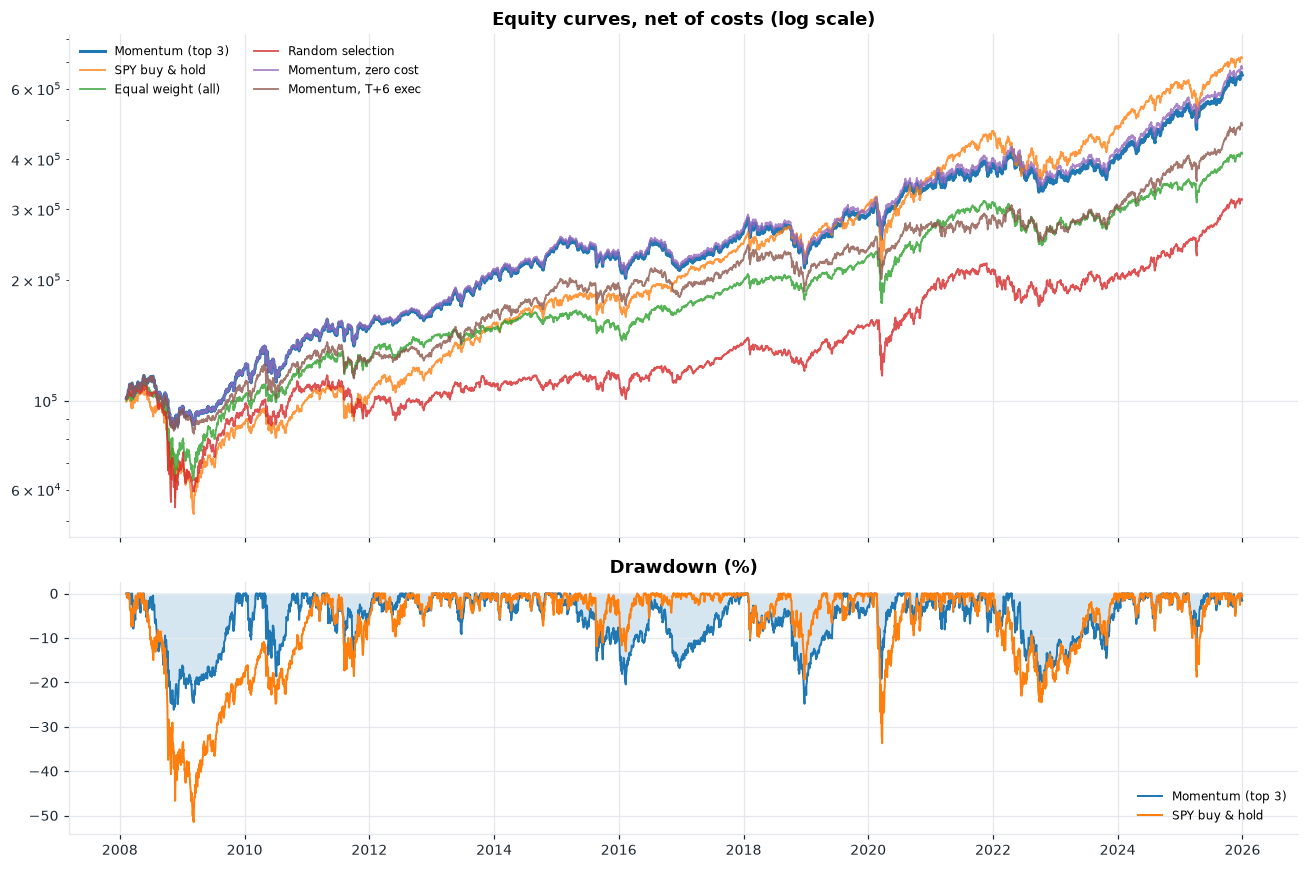

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
for name, r in results.items():
    axes[0].plot(r.equity.index, r.equity.values, lw=2.0 if name == strategy.name else 1.2,
                 label=name, alpha=1.0 if name == strategy.name else 0.8)
axes[0].set_yscale("log")
axes[0].set_title("Equity curves, net of costs (log scale)")
axes[0].legend(fontsize=8, ncol=2)

for name in [strategy.name, "SPY buy & hold"]:
    dd = metrics.drawdown_series(results[name].equity)
    axes[1].plot(dd.index, dd * 100, label=name, lw=1.3)
axes[1].fill_between(metrics.drawdown_series(strategy.equity).index,
                     metrics.drawdown_series(strategy.equity) * 100, 0, alpha=0.18)
axes[1].set_title("Drawdown (%)")
axes[1].legend(fontsize=8)
plt.tight_layout()

## In-sample vs out-of-sample

In [6]:
splits = validation.make_splits(strategy.index, "2018-12-31", "2022-12-31", "2025-12-31")
for s in splits:
    print(" ", s)

split_metrics = validation.evaluate_splits(strategy, splits, benchmark=benchmark)
split_metrics.loc[["cagr", "ann_volatility", "sharpe", "max_drawdown", "calmar", "win_rate"]].round(3)

  training: 2008-02-01 -> 2018-12-31 (in-sample; parameters chosen here)
  validation: 2019-01-01 -> 2022-12-31 (out-of-sample check)
  test: 2023-01-01 -> 2025-12-30 (final; evaluated once)
  full: 2008-02-01 -> 2025-12-30 (entire sample)


,training,validation,test,full
cagr,0.075491,0.119726,0.225601,0.109115
ann_volatility,0.150615,0.153485,0.136939,0.149077
sharpe,0.558649,0.813843,1.554227,0.769425
max_drawdown,-0.261766,-0.20492,-0.137997,-0.261766
calmar,0.28839,0.584257,1.634824,0.416843
win_rate,0.54294,0.555556,0.568575,0.550033


Training Sharpe is the *lowest* of the three periods here, which is the opposite of the usual
overfitting signature. That is reassuring — but it also reflects that the training window
contains the 2008-09 crisis, and later periods were kinder to almost everything.

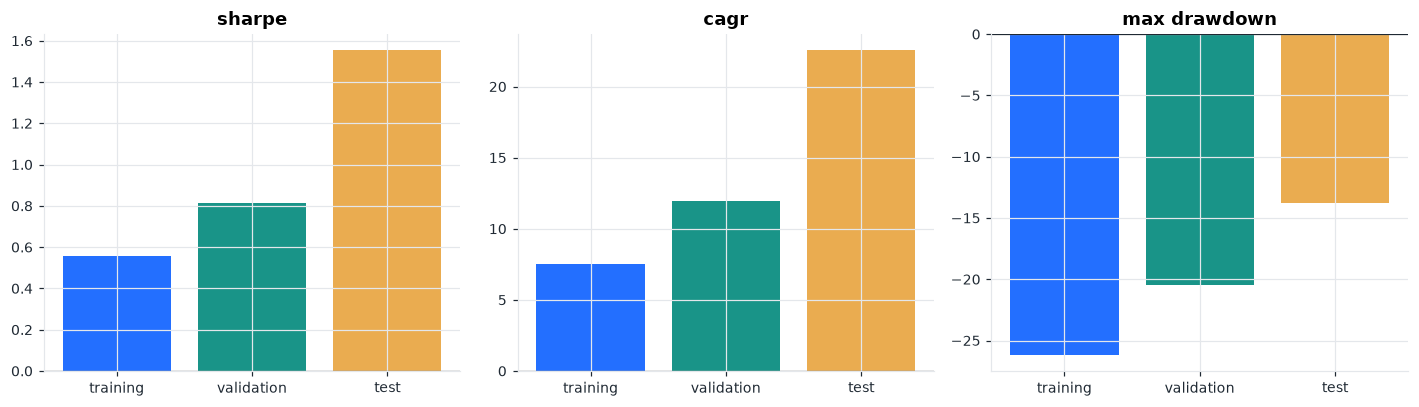

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
cols = [c for c in ["training", "validation", "test"] if c in split_metrics.columns]
for ax, metric in zip(axes, ["sharpe", "cagr", "max_drawdown"]):
    vals = [split_metrics.loc[metric, c] for c in cols]
    scale = 100 if metric in ("cagr", "max_drawdown") else 1
    ax.bar(cols, [v * scale for v in vals], color=["#0B5FFF", "#00897B", "#E8A33D"], alpha=0.9)
    ax.set_title(metric.replace("_", " "))
    ax.axhline(0, color="#1F2933", lw=0.8)
plt.tight_layout()

## Rolling stability

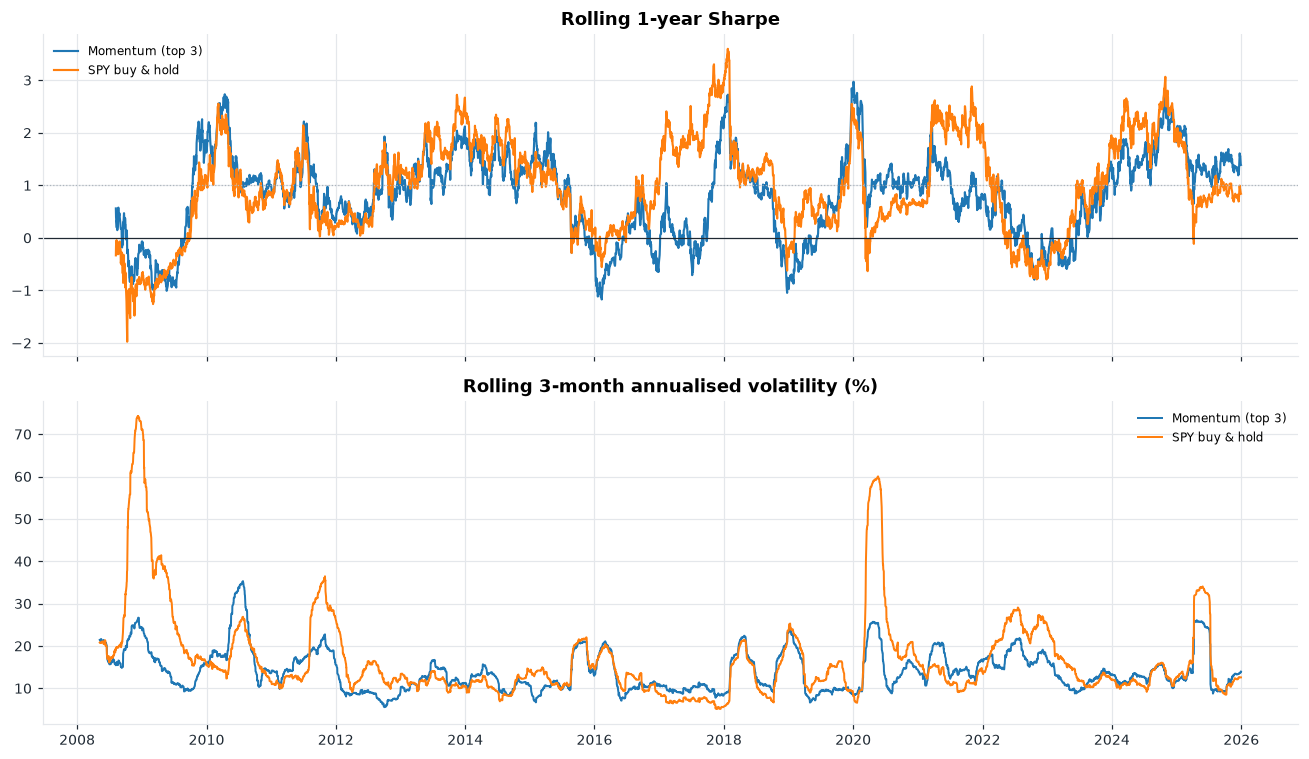

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for name in [strategy.name, "SPY buy & hold"]:
    rs = metrics.rolling_sharpe(results[name].net_returns, 252)
    axes[0].plot(rs.index, rs.values, label=name, lw=1.4)
axes[0].axhline(0, color="#1F2933", lw=0.8)
axes[0].axhline(1, color="#ADB5BD", lw=0.8, ls=":")
axes[0].set_title("Rolling 1-year Sharpe")
axes[0].legend(fontsize=8)

for name in [strategy.name, "SPY buy & hold"]:
    rv = results[name].net_returns.rolling(63).std(ddof=1) * np.sqrt(252)
    axes[1].plot(rv.index, rv * 100, label=name, lw=1.3)
axes[1].set_title("Rolling 3-month annualised volatility (%)")
axes[1].legend(fontsize=8)
plt.tight_layout()

## Monthly returns

In [9]:
table = metrics.monthly_return_table(strategy.net_returns)
table.style.format("{:.2%}", na_rep="").background_gradient(cmap="RdYlGn", axis=None, vmin=-0.12, vmax=0.12)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year
year,,,,,,,,,,,,,
2008,,6.14%,-3.34%,3.63%,3.75%,1.76%,-5.43%,-4.42%,-1.30%,-14.45%,4.53%,6.14%,-4.94%
2009,-4.01%,-3.99%,4.07%,0.73%,3.20%,-0.46%,3.87%,1.33%,6.15%,-0.67%,8.97%,3.03%,23.66%
2010,-5.20%,3.99%,8.69%,4.20%,-7.39%,-6.31%,3.60%,4.28%,6.99%,1.25%,1.23%,5.75%,21.36%
2011,-1.22%,4.45%,0.16%,6.37%,-2.89%,-2.63%,0.85%,1.15%,-10.03%,9.35%,1.20%,-0.93%,4.59%
2012,6.40%,-2.18%,-0.13%,1.17%,-1.03%,2.58%,2.33%,1.28%,-1.12%,-2.82%,0.75%,1.34%,8.56%
2013,3.81%,0.37%,2.66%,2.71%,0.03%,-2.01%,5.91%,-2.70%,5.82%,3.44%,2.65%,2.48%,27.79%
2014,-2.74%,4.83%,-0.89%,-1.13%,2.53%,2.00%,-0.93%,3.03%,-2.76%,4.95%,3.39%,0.97%,13.63%
2015,4.84%,-0.97%,0.18%,-2.46%,-0.11%,-3.68%,4.17%,-6.42%,-3.23%,5.46%,-0.29%,-0.53%,-3.69%
2016,-5.82%,-0.65%,5.64%,0.36%,-1.07%,7.68%,2.81%,-2.66%,-0.86%,-4.34%,-6.06%,-0.89%,-6.61%


## Parameter sensitivity — training window only

Searching this grid on the test period and reporting the best cell is how a backtest becomes
fiction. With 192 combinations, a high Sharpe *somewhere* is what noise produces.

In [10]:
train = splits[0]
sensitivity = validation.run_sensitivity(
    prices, returns,
    lookback_months=[3, 6, 9, 12], holdings_grid=[1, 2, 3, 4],
    rebalance_grid=["weekly", "monthly", "quarterly"], cost_grid=[0, 5, 10, 20],
    skip=21, max_weight=0.40, execution_lag=1,
    eval_start=train.start, eval_end=train.end,
)
print(f"{len(sensitivity)} combinations on {train.start.date()} -> {train.end.date()}")
sensitivity["sharpe"].describe().round(3)

192 combinations on 2008-02-01 -> 2018-12-31


count    192.000
mean       0.357
std        0.149
min       -0.054
25%        0.255
50%        0.370
75%        0.469
max        0.605
Name: sharpe, dtype: float64

In [11]:
marginals = validation.sensitivity_marginals(sensitivity, "sharpe")
for dim, table in marginals.items():
    print(f"\n--- {dim} ---")
    print(table.to_string())


--- lookback_months ---
                   mean  median     std     min     max  count
lookback_months                                               
3                0.4103  0.4208  0.1028  0.0331  0.6048     48
6                0.3960  0.4344  0.1213  0.1245  0.5932     48
9                0.2786  0.2494  0.1707 -0.0537  0.5849     48
12               0.3417  0.3169  0.1577 -0.0008  0.5732     48

--- holdings ---
            mean  median     std     min     max  count
holdings                                               
1         0.2187  0.2241  0.1515 -0.0537  0.5255     48
2         0.3135  0.3004  0.1111  0.1448  0.5744     48
3         0.4158  0.4188  0.0998  0.2112  0.6048     48
4         0.4785  0.4701  0.0703  0.2852  0.5849     48

--- rebalance ---
             mean  median     std     min     max  count
rebalance                                               
monthly    0.4048  0.4373  0.1266  0.1048  0.5849     64
quarterly  0.2783  0.3104  0.1425 -0.0537  0.4693    

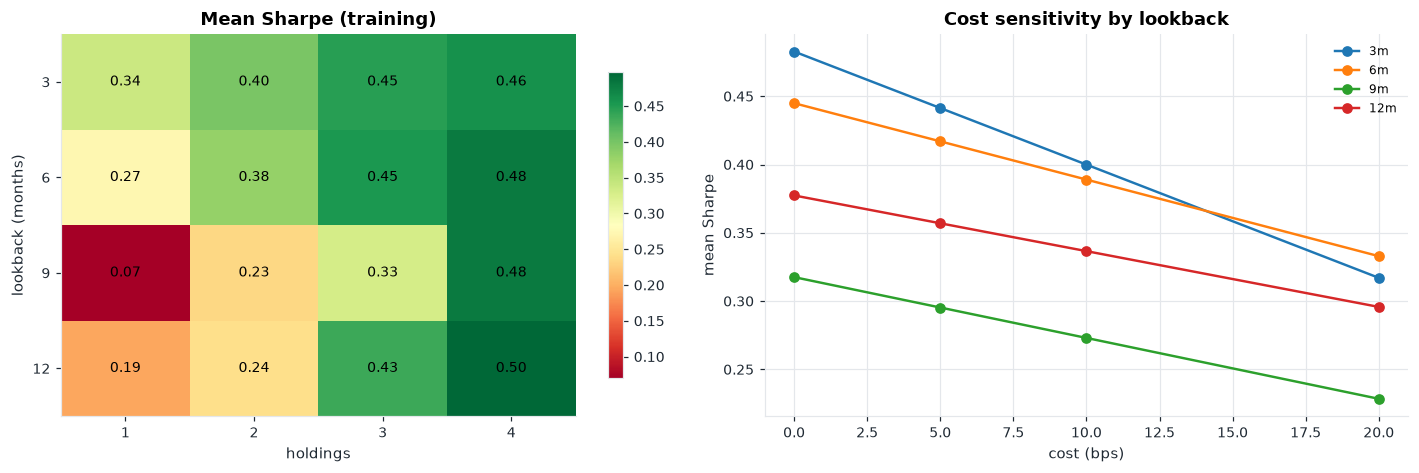

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

pivot = sensitivity.pivot_table(index="lookback_months", columns="holdings",
                                values="sharpe", aggfunc="mean")
im = axes[0].imshow(pivot.values, cmap="RdYlGn", aspect="auto")
axes[0].set_xticks(range(len(pivot.columns)), pivot.columns)
axes[0].set_yticks(range(len(pivot.index)), pivot.index)
axes[0].set_xlabel("holdings"); axes[0].set_ylabel("lookback (months)")
axes[0].set_title("Mean Sharpe (training)")
axes[0].grid(False)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        axes[0].text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=axes[0], shrink=0.8)

for months, grp in sensitivity.groupby("lookback_months"):
    by_cost = grp.groupby("cost_bps")["sharpe"].mean()
    axes[1].plot(by_cost.index, by_cost.values, marker="o", label=f"{months}m")
axes[1].set_xlabel("cost (bps)"); axes[1].set_ylabel("mean Sharpe")
axes[1].set_title("Cost sensitivity by lookback")
axes[1].legend(fontsize=8)
plt.tight_layout()

Look for a **broad stable region**, not the single best cell. Neighbouring parameters giving
wildly different answers means the surface is measuring noise.

## Regimes

In [13]:
regimes = validation.regime_analysis(strategy.net_returns, benchmark)
regimes.round(4)

,n_days,pct_of_sample,strategy_ann_return,benchmark_ann_return,strategy_ann_vol,strategy_sharpe,benchmark_sharpe,excess_ann_return,win_rate
Benchmark up,3417.0,0.7590,0.1723,0.2395,0.1323,1.2684,1.6715,-0.0671,0.5660
Benchmark down,960.0,0.2132,-0.0819,-0.2133,0.1926,-0.3477,-0.5305,0.1314,0.4990
Vol: low,1480.0,0.3287,0.0480,0.1080,0.1141,0.4684,1.0543,-0.0600,0.5351
Vol: mid,1480.0,0.3287,0.1285,0.1369,0.1448,0.9080,0.9612,-0.0084,0.5723
Vol: high,1480.0,0.3287,0.1451,0.1014,0.1778,0.8506,0.4741,0.0436,0.5412


,strategy,benchmark,excess
date,,,
2008,-0.0494,-0.3100,0.2606
2009,0.2366,0.2635,-0.0269
2010,0.2136,0.1506,0.0630
2011,0.0459,0.0189,0.0269
2012,0.0856,0.1599,-0.0743
2013,0.2779,0.3231,-0.0452
2014,0.1363,0.1346,0.0017
2015,-0.0369,0.0123,-0.0493
2016,-0.0661,0.1200,-0.1861


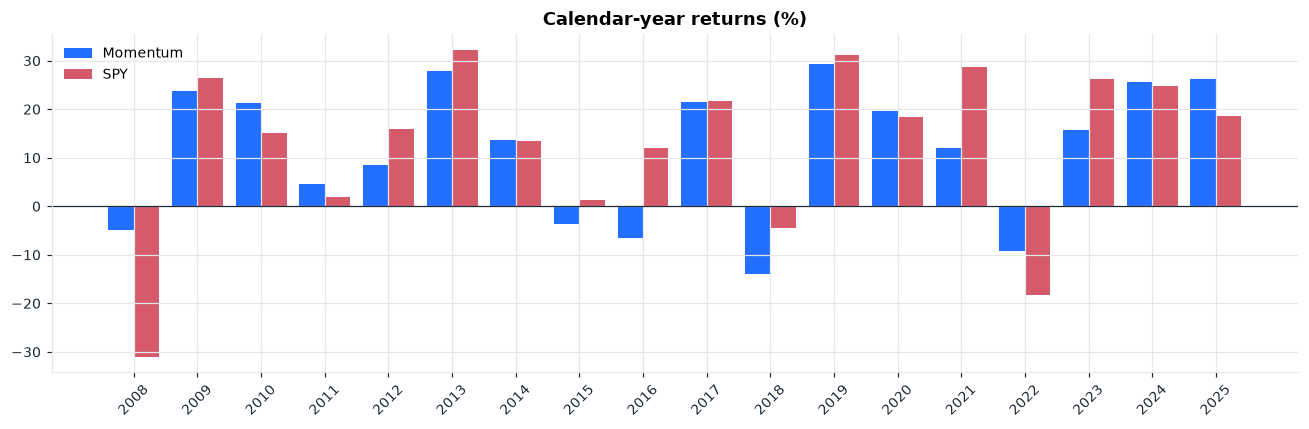

In [14]:
years = validation.calendar_year_table(strategy.net_returns, benchmark)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(years))
ax.bar(x - 0.2, years["strategy"] * 100, width=0.4, label="Momentum", color="#0B5FFF", alpha=0.9)
ax.bar(x + 0.2, years["benchmark"] * 100, width=0.4, label="SPY", color="#D1495B", alpha=0.9)
ax.set_xticks(x, years.index, rotation=45)
ax.axhline(0, color="#1F2933", lw=0.8)
ax.set_title("Calendar-year returns (%)")
ax.legend()
plt.tight_layout()

years.round(4)

## Conclusion

The strategy delivers a higher Sharpe and roughly half the drawdown of SPY, but **less absolute
return**. Whether that is worth having depends on whether the investor can lever it, or values
the shallower drawdown for its own sake.

It beats random 3-of-9 selection by a clear margin, which is the evidence that the ranking
carries information rather than the universe simply being forgiving.

For the full write-up including failure analysis and limitations, run:

```bash
python -m quant_platform.run --config configs/momentum.yaml
```